In [1]:
import torch
import os
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm.notebook import tqdm
from DenseTCN import  DenseTCN,TDEJointLoss
from TCN_TDE import TCN, tcn_loss,spatial_diffusion_loss

In [2]:

# ================= 1. 设置相对路径并创建目录 =================
BASE_DIR = './model'
os.makedirs(BASE_DIR, exist_ok=True)
MODEL_SAVE_PATH = os.path.join(BASE_DIR, 'tcn_delay_model.pth')
LOSS_PLOT_PATH = os.path.join(BASE_DIR, 'loss_curve.png')

# ================= 2. 数据集构建与软件时延模拟 =================
class DelayEstimationDataset(Dataset):
    def __init__(self, num_samples, seq_length, max_delay, mode='train'):
        self.num_samples = num_samples
        self.seq_length = seq_length
        self.max_delay = max_delay
        self.mode = mode

        # 预生成所有数据，避免训练时动态生成导致的IO瓶颈
        self.signals = np.random.randn(num_samples, seq_length).astype(np.float32)
        self.delays = np.random.randint(-max_delay, max_delay + 1, size=num_samples)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        signal = self.signals[idx]
        delay = self.delays[idx]

        # 软件时延模拟：通过循环移位实现
        delayed_signal = np.roll(signal, delay)

        # 数据维度匹配：将两个通道堆叠为 (seq_length, 2)
        input_data = np.stack([signal, delayed_signal], axis=-1)

        return torch.tensor(input_data, dtype=torch.float32), torch.tensor(delay, dtype=torch.float32)



Training on: cuda


Epoch 1/20 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

D:\Anaconda\envs\torch\Lib\site-packages\torch\nn\functional.py:2994: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


Epoch 1/20 [Test] :   0%|          | 0/32 [00:00<?, ?it/s]

>> Epoch 1 Summary | Train Loss: 7.3597 | Test Loss: 7.6255



...

Epoch 19/20 [Test] :   0%|          | 0/32 [00:00<?, ?it/s]

>> Epoch 19 Summary | Train Loss: 0.0441 | Test Loss: 0.0374



Epoch 20/20 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 [Test] :   0%|          | 0/32 [00:00<?, ?it/s]

>> Epoch 20 Summary | Train Loss: 0.0454 | Test Loss: 0.0298

[Success] Model saved to: ./tcn_delay_results\tcn_delay_model.pth


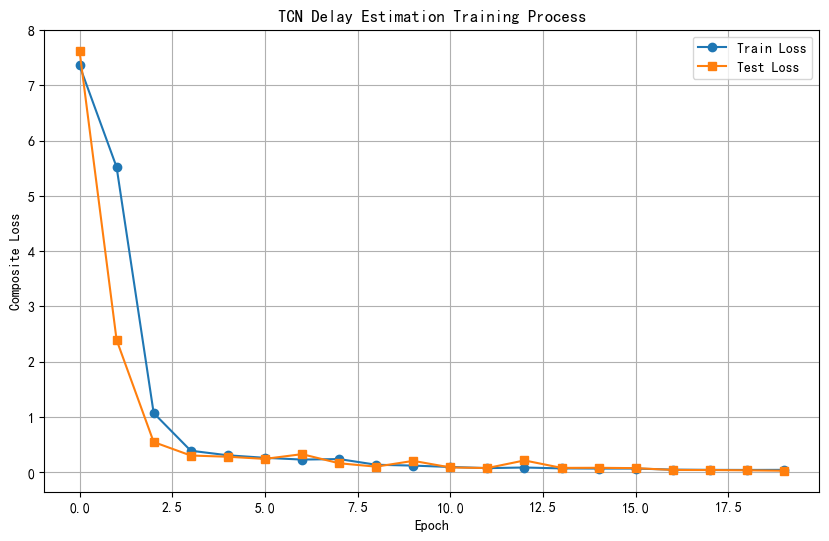

[Success] Loss curve saved to: ./tcn_delay_results\loss_curve.png


In [3]:

# ================= 4. 训练配置与执行 =================
# 超参数设置
SEQ_LENGTH = 1000
MAX_DELAY = 50
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 1e-3

# 划分数据集 (80% 训练集, 20% 测试集)
train_dataset = DelayEstimationDataset(num_samples=8000, seq_length=SEQ_LENGTH, max_delay=MAX_DELAY)
test_dataset = DelayEstimationDataset(num_samples=2000, seq_length=SEQ_LENGTH, max_delay=MAX_DELAY)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 初始化模型、优化器
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TCN(input_dim=2,enc_dim=64,bottle_neck_dim=16,hidden_dim=64,
            layer=6,stack=2,max_delay=MAX_DELAY).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 训练循环 (带进度条)
train_losses, test_losses = [], []
print(f"Training on: {device}")

for epoch in range(EPOCHS):
    # --- 训练阶段 ---
    model.train()
    running_train_loss = 0.0
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=True)
    for batch_x, batch_y in train_pbar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = tcn_loss(outputs, batch_y, MAX_DELAY)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        train_pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- 测试阶段 ---
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        test_pbar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Test] ", leave=True)
        for batch_x, batch_y in test_pbar:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = tcn_loss(outputs, batch_y, MAX_DELAY)
            running_test_loss += loss.item()

    avg_test_loss = running_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    print(f">> Epoch {epoch+1} Summary | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}\n")

# ================= 5. 结果保存与可视化 =================
# 1. 保存模型权重到相对路径
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"[Success] Model saved to: {MODEL_SAVE_PATH}")

# 2. 绘制并保存 Loss 曲线
plt.figure(figsize=(10, 6))
plt.rcParams['font.sans-serif'] = ['SimHei']

# 2. 解决负号 '-' 显示为方块的问题（强烈建议加上）
plt.rcParams['axes.unicode_minus'] = False
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(test_losses, label='Test Loss', marker='s')
plt.title('TCN Delay Estimation Training Process')
plt.xlabel('Epoch')
plt.ylabel('Composite Loss')
plt.legend()
plt.grid(True)
plt.savefig(LOSS_PLOT_PATH, dpi=150)
plt.show()
print(f"[Success] Loss curve saved to: {LOSS_PLOT_PATH}")

Validating:   0%|          | 0/100 [00:00<?, ?it/s]


验证结果汇总
样本数量: 100
MAE (平均绝对误差): 0.4494 样本
RMSE (均方根误差): 0.6612 样本
误差 ≤ 1 样本的准确率: 89.00%
误差 ≤ 3 样本的准确率: 100.00%


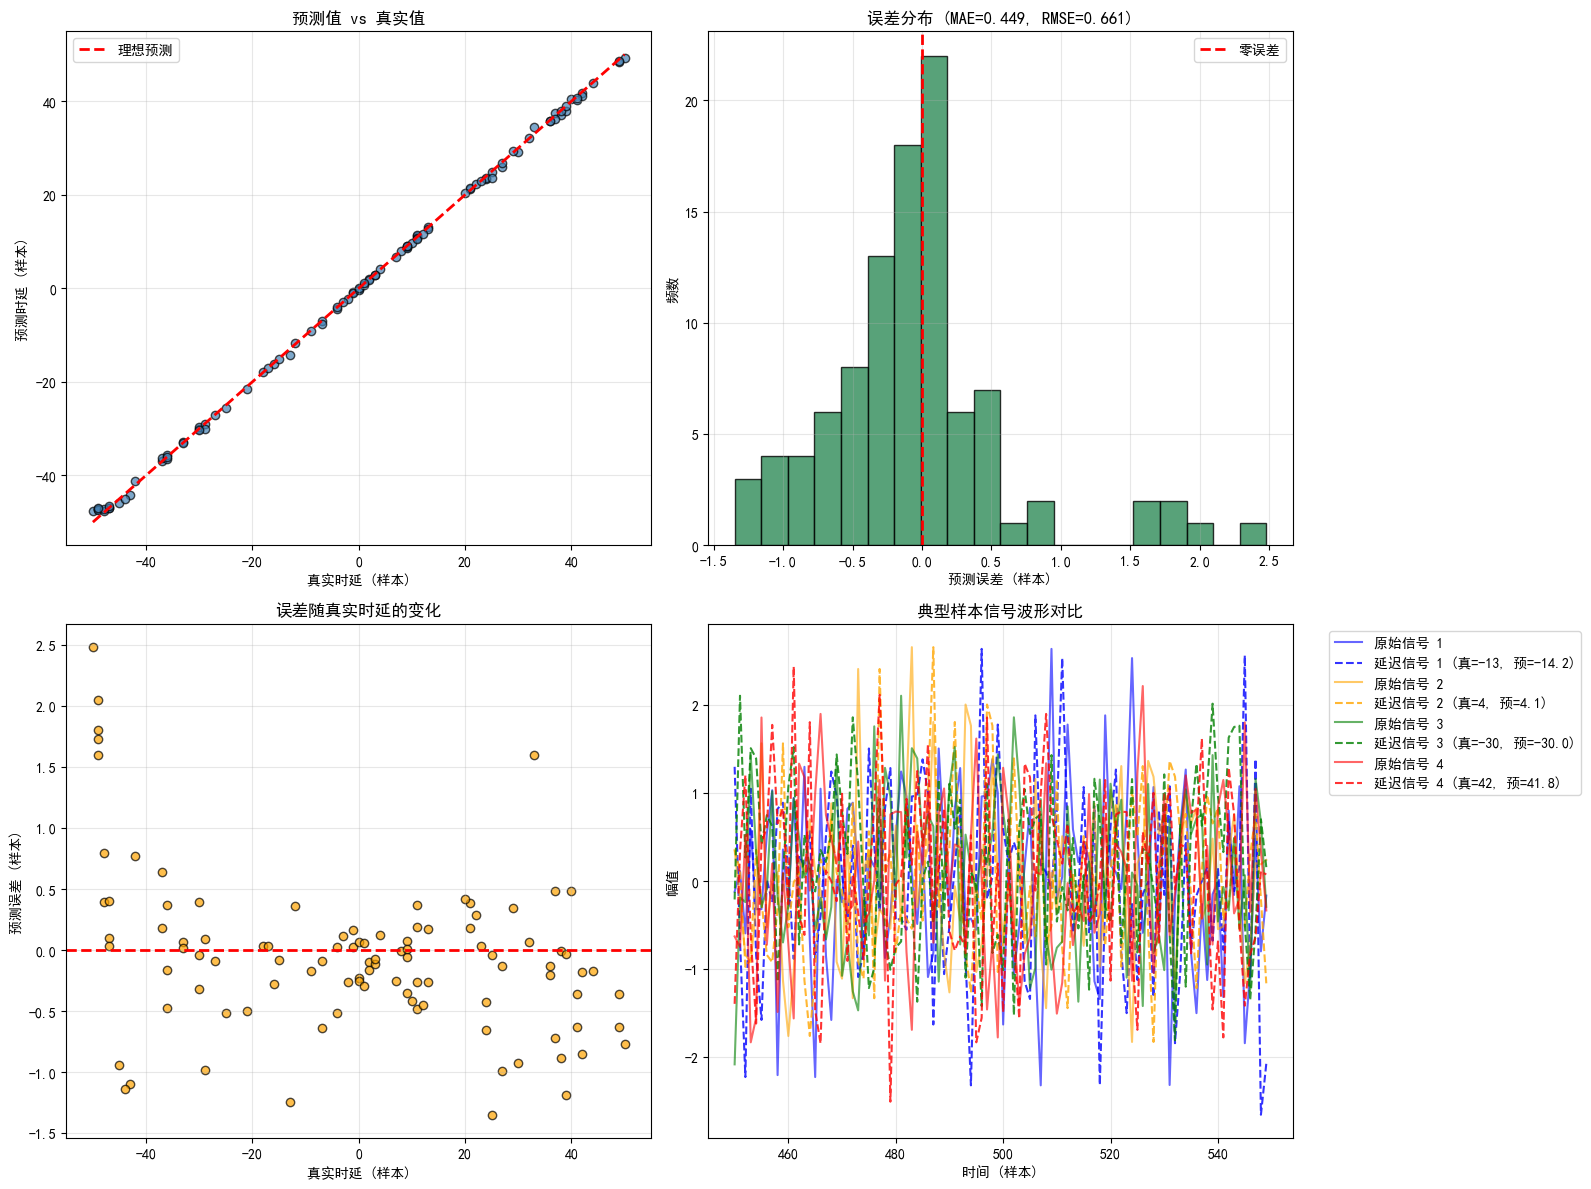

[Success] 验证结果已保存至: ./tcn_delay_results\validation_results.npz

详细预测结果 (前20个样本):
--------------------------------------------------
样本     真实时延         预测时延         误差          
--------------------------------------------------
0      -13          -14.246      -1.246      
1      4            4.126        0.126       
2      -30          -30.038      -0.038      
3      42           41.820       -0.180      
4      -12          -11.637      0.363       
5      2            1.903        -0.097      
6      -18          -17.963      0.037       
7      27           26.010       -0.990      
8      37           37.485       0.485       
9      -50          -47.520      2.480       
10     36           35.865       -0.135      
11     11           11.185       0.185       
12     30           29.077       -0.923      
13     -47          -46.904      0.096       
14     50           49.233       -0.767      
15     -49          -47.275      1.725       
16     -33          -32.932      0.

In [4]:
# ================= 6.训练模型拟合演示  =================

# ================= 6. 验证数据生成与模型预测 =================
def generate_validation_data(num_samples, seq_length, max_delay):
    """生成验证数据，包含多种时延场景"""
    np.random.seed(42)  # 固定随机种子，确保结果可复现
    
    # 覆盖多种时延场景：均匀分布 + 边界值 + 零时延
    delays_uniform = np.random.randint(-max_delay, max_delay + 1, num_samples - 6)
    delays_special = [-max_delay, -max_delay//2, -1, 0, 1, max_delay//2]  # 边界和特殊值
    delays = np.concatenate([delays_uniform, delays_special])
    np.random.shuffle(delays)
    
    signals = np.random.randn(num_samples, seq_length).astype(np.float32)
    validation_data = []
    
    for signal, delay in zip(signals, delays):
        delayed_signal = np.roll(signal, delay)
        input_data = np.stack([signal, delayed_signal], axis=-1)
        validation_data.append((input_data, delay))
    
    return validation_data

# 生成验证数据
VAL_SAMPLES = 100
validation_data = generate_validation_data(VAL_SAMPLES, SEQ_LENGTH, MAX_DELAY)

# 模型预测
model.eval()
predictions = []
true_delays = []

with torch.no_grad():
    for input_data, true_delay in tqdm(validation_data, desc="Validating"):
        input_tensor = torch.tensor(input_data, dtype=torch.float32).unsqueeze(0).to(device)
        output = model(input_tensor)
        
        # 从概率分布中获取预测时延（期望值）
        delays_range = torch.arange(-MAX_DELAY, MAX_DELAY + 1, device=device, dtype=torch.float32)
        pred_delay = torch.sum(output * delays_range).item()
        
        predictions.append(pred_delay)
        true_delays.append(true_delay)

predictions = np.array(predictions)
true_delays = np.array(true_delays)

# 计算评估指标
mae = np.mean(np.abs(predictions - true_delays))
rmse = np.sqrt(np.mean((predictions - true_delays) ** 2))
accuracy_1sample = np.mean(np.abs(predictions - true_delays) <= 1)  # 误差≤1样本的比例
accuracy_3sample = np.mean(np.abs(predictions - true_delays) <= 3)  # 误差≤3样本的比例

print("\n" + "="*50)
print("验证结果汇总")
print("="*50)
print(f"样本数量: {VAL_SAMPLES}")
print(f"MAE (平均绝对误差): {mae:.4f} 样本")
print(f"RMSE (均方根误差): {rmse:.4f} 样本")
print(f"误差 ≤ 1 样本的准确率: {accuracy_1sample*100:.2f}%")
print(f"误差 ≤ 3 样本的准确率: {accuracy_3sample*100:.2f}%")
print("="*50)

# ================= 7. 可视化对比 =================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 图1: 预测值 vs 真实值散点图
axes[0, 0].scatter(true_delays, predictions, alpha=0.7, color='steelblue', edgecolors='black')
axes[0, 0].plot([-MAX_DELAY, MAX_DELAY], [-MAX_DELAY, MAX_DELAY], 'r--', lw=2, label='理想预测')
axes[0, 0].set_xlabel('真实时延 (样本)')
axes[0, 0].set_ylabel('预测时延 (样本)')
axes[0, 0].set_title('预测值 vs 真实值')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 图2: 误差分布直方图
errors = predictions - true_delays
axes[0, 1].hist(errors, bins=20, color='seagreen', edgecolor='black', alpha=0.8)
axes[0, 1].axvline(0, color='red', linestyle='--', lw=2, label='零误差')
axes[0, 1].set_xlabel('预测误差 (样本)')
axes[0, 1].set_ylabel('频数')
axes[0, 1].set_title(f'误差分布 (MAE={mae:.3f}, RMSE={rmse:.3f})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 图3: 误差随真实时延的变化
axes[1, 0].scatter(true_delays, errors, alpha=0.7, color='orange', edgecolors='black')
axes[1, 0].axhline(0, color='red', linestyle='--', lw=2)
axes[1, 0].set_xlabel('真实时延 (样本)')
axes[1, 0].set_ylabel('预测误差 (样本)')
axes[1, 0].set_title('误差随真实时延的变化')
axes[1, 0].grid(True, alpha=0.3)

# 图4: 选取几个典型样本，展示信号波形与预测结果
sample_indices = [0, 1, 2, 3]
colors = ['blue', 'orange', 'green', 'red']
for i, idx in enumerate(sample_indices):
    signal = validation_data[idx][0][:, 0]  # 原始信号
    delayed_signal = validation_data[idx][0][:, 1]  # 延迟信号
    true_delay = true_delays[idx]
    pred_delay = predictions[idx]
    
    # 截取一段展示
    start = SEQ_LENGTH // 2 - 50
    end = SEQ_LENGTH // 2 + 50
    t = np.arange(start, end)
    axes[1, 1].plot(t, signal[start:end], color=colors[i], alpha=0.6, label=f'原始信号 {i+1}')
    axes[1, 1].plot(t, delayed_signal[start:end], color=colors[i], linestyle='--', alpha=0.8, 
                   label=f'延迟信号 {i+1} (真={true_delay}, 预={pred_delay:.1f})')

axes[1, 1].set_xlabel('时间 (样本)')
axes[1, 1].set_ylabel('幅值')
axes[1, 1].set_title('典型样本信号波形对比')
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'validation_results.png'), dpi=150, bbox_inches='tight')
plt.show()

# ================= 8. 保存验证结果 =================
validation_results = {
    'true_delays': true_delays,
    'predictions': predictions,
    'errors': errors,
    'mae': mae,
    'rmse': rmse,
    'accuracy_1sample': accuracy_1sample,
    'accuracy_3sample': accuracy_3sample
}
np.savez(os.path.join(BASE_DIR, 'validation_results.npz'), **validation_results)
print(f"[Success] 验证结果已保存至: {os.path.join(BASE_DIR, 'validation_results.npz')}")

# 打印详细预测结果表格
print("\n详细预测结果 (前20个样本):")
print("-" * 50)
print(f"{'样本':<6} {'真实时延':<12} {'预测时延':<12} {'误差':<12}")
print("-" * 50)
for i in range(min(20, VAL_SAMPLES)):
    print(f"{i:<6} {true_delays[i]:<12} {predictions[i]:<12.3f} {errors[i]:<12.3f}")





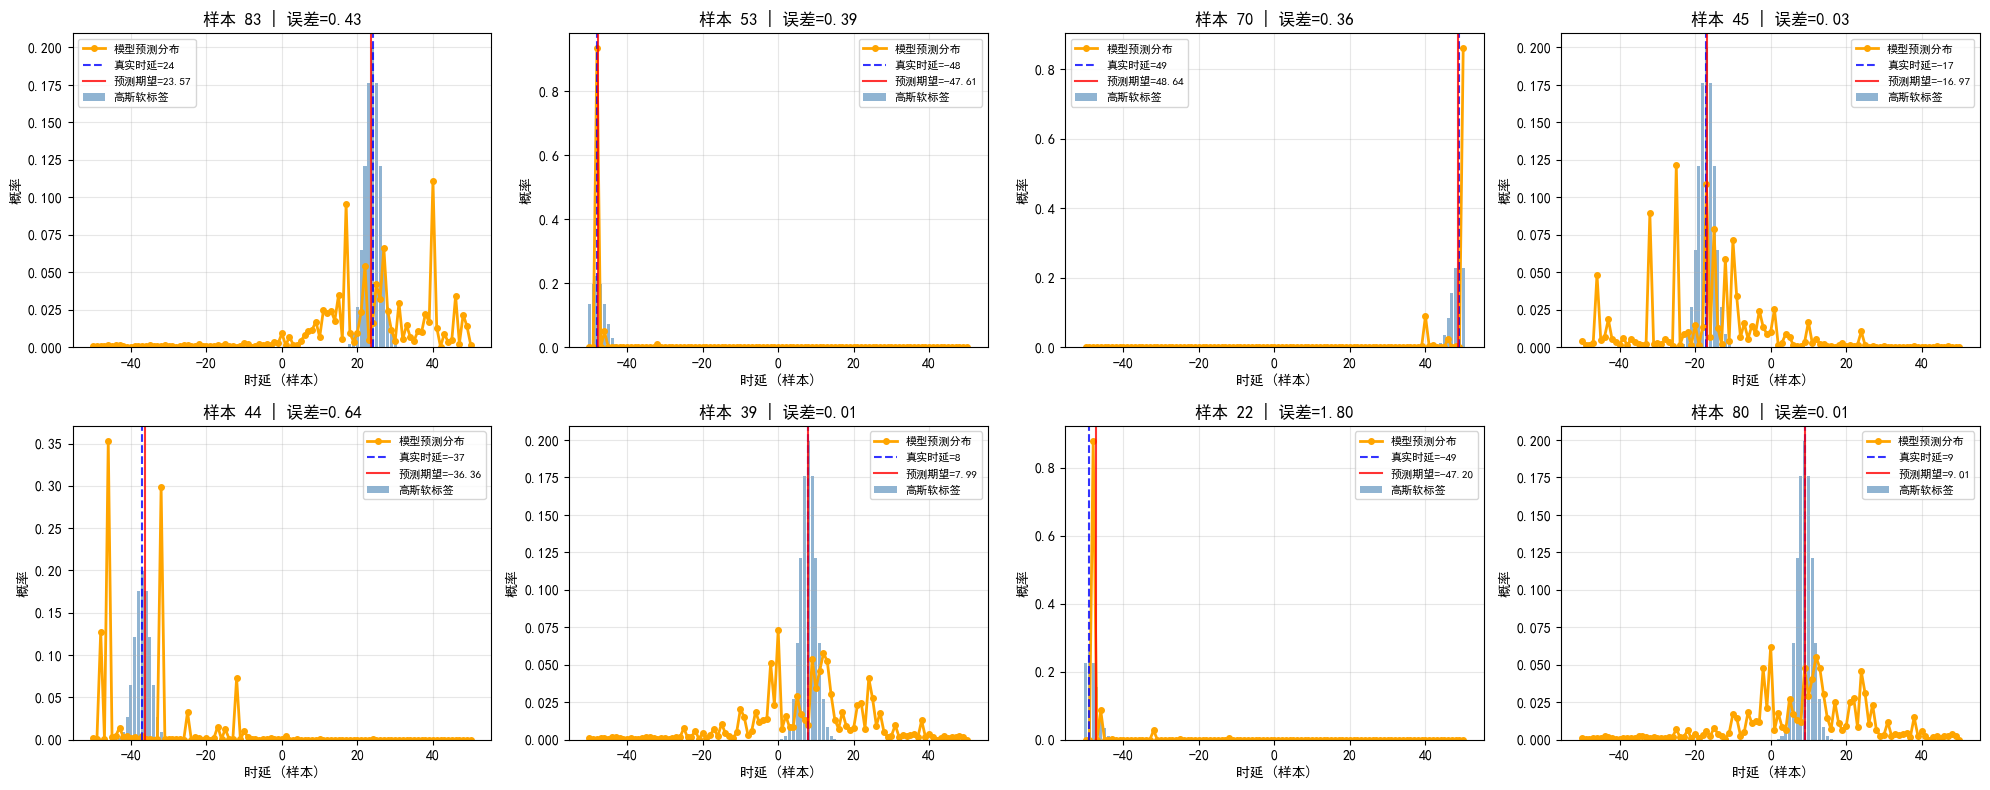

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [5]:
# ================= 9. 预测分布 vs 高斯软标签对比 =================
def plot_distribution_comparison(validation_data, model, device, max_delay, num_samples=8):
    """绘制预测概率分布与高斯软标签的对比图"""
    model.eval()
    
    # 随机选取 num_samples 个样本进行展示
    np.random.seed(42)
    sample_indices = np.random.choice(len(validation_data), num_samples, replace=False)
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    axes = axes.flatten()
    
    delays_range = np.arange(-max_delay, max_delay + 1)
    
    for i, idx in enumerate(sample_indices):
        input_data, true_delay = validation_data[idx]
        input_tensor = torch.tensor(input_data, dtype=torch.float32).unsqueeze(0).to(device)
        
        # 获取模型输出的概率分布
        with torch.no_grad():
            output = model(input_tensor).cpu().numpy().flatten()
        
        # 生成对应的高斯软标签
        sigma = 2.0
        gaussian_label = np.exp(-0.5 * ((delays_range - true_delay) / sigma) ** 2)
        gaussian_label = gaussian_label / gaussian_label.sum()
        
        # 计算预测期望值
        pred_delay = np.sum(output * delays_range)
        
        # 绘制对比
        ax = axes[i]
        ax.bar(delays_range, gaussian_label, width=0.8, alpha=0.6, color='steelblue', 
               label='高斯软标签', edgecolor='none')
        ax.plot(delays_range, output, 'o-', color='orange', markersize=4, lw=2, 
                label='模型预测分布')
        ax.axvline(true_delay, color='blue', linestyle='--', lw=1.5, alpha=0.8, label=f'真实时延={true_delay}')
        ax.axvline(pred_delay, color='red', linestyle='-', lw=1.5, alpha=0.8, label=f'预测期望={pred_delay:.2f}')
        
        ax.set_xlabel('时延 (样本)')
        ax.set_ylabel('概率')
        ax.set_title(f'样本 {idx} | 误差={abs(pred_delay - true_delay):.2f}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'distribution_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

# 执行分布对比可视化
plot_distribution_comparison(validation_data, model, device, MAX_DELAY, num_samples=8)

# ================= 10. 整体分布对比统计图 =================
# 收集所有样本的预测分布和软标签，做整体统计
all_predictions_dist = []
all_gaussian_labels = []

model.eval()
with torch.no_grad():
    for input_data, true_delay in validation_data:
        input_tensor = torch.tensor(input_data, dtype=torch.float32).unsqueeze(0).to(device)
        output = model(input_tensor).cpu().numpy().flatten()
        all_predictions_dist.append(output)
        
        sigma = 2.0
        gaussian_label = np.exp(-0.5 * ((delays_range - true_delay) / sigma) ** 2)
        gaussian_label = gaussian_label / gaussian_label.sum()
        all_gaussian_labels.append(gaussian_label)

all_predictions_dist = np.array(all_predictions_dist)
all_gaussian_labels = np.array(all_gaussian_labels)

# 计算每个时延位置的平均分布
mean_pred_dist = all_predictions_dist.mean(axis=0)
mean_gauss_dist = all_gaussian_labels.mean(axis=0)

# 计算KL散度（衡量两个分布的差异）
from scipy.stats import entropy
kl_divs = [entropy(all_gaussian_labels[i], all_predictions_dist[i]) for i in range(len(validation_data))]
mean_kl_div = np.mean(kl_divs)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(delays_range, mean_gauss_dist, 'o-', color='steelblue', markersize=6, lw=2.5, label='平均高斯软标签')
ax.plot(delays_range, mean_pred_dist, 's-', color='orange', markersize=4, lw=2, label='平均预测分布')
ax.set_xlabel('时延 (样本)')
ax.set_ylabel('平均概率')
ax.set_title(f'整体分布对比 | 平均KL散度={mean_kl_div:.4f}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig(os.path.join(BASE_DIR, 'mean_distribution_comparison.png'), dpi=150)
plt.show()

print(f"[Success] 分布对比图已保存至: {os.path.join(BASE_DIR, 'distribution_comparison.png')}")
print(f"[Success] 整体分布对比图已保存至: {os.path.join(BASE_DIR, 'mean_distribution_comparison.png')}")
print(f"平均KL散度: {mean_kl_div:.4f} (越小表示预测分布越接近高斯软标签)")